# **Notebook 3: Bio_ClinicalBERT Residual Gated Fusion Ablation**

**Description:** This notebook tests whether the Bio_ClinicalBERT fusion path from Notebook 02 improves when the standard fusion layer is replaced with a residual gated fusion block. The saved splits, five-class label space, dual-view ResNet18 image encoder, Bio_ClinicalBERT text branch, optimizer setup, and evaluation protocol are kept aligned so the main experimental change is the fusion architecture.

**Main Questions This Notebook Should Answer:**
- Does gated image/text interaction improve held-out performance?
- Is the macro-F1 gain strong enough to justify carrying the architecture forward?
- Should residual gated fusion become the model family used for segmentation, tuning, and final interpretability?

---

# **Part 1: Configuration**
### **Imports**


In [15]:
from pathlib import Path
import ast
import json
import random
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from transformers import AutoTokenizer, AutoModel, BertConfig, BertModel
from transformers.utils.hub import cached_file


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


project_root = Path.cwd().resolve()
base_dir = project_root if (project_root / "splits").exists() else project_root.parent
split_dir = base_dir / "splits"

train_csv = split_dir / "train.csv"
val_csv = split_dir / "val.csv"
test_csv = split_dir / "test.csv"

HF_CACHE_DIR = base_dir / "hf_cache"

IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
EPOCHS = 10
LR_TEXT = 2e-5
LR_IMAGE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_LEN = 64
FREEZE_BERT = True
FREEZE_IMAGE_BACKBONE = False
LR_SCHEDULE_NAME = "constant"

NOTEBOOK02_EXPERIMENT_NAME = "experiment_02_text_encoder_benchmark"
NOTEBOOK02_OUTPUT_DIR = (
    base_dir / "Experiments" / "outputs" / NOTEBOOK02_EXPERIMENT_NAME
)
NOTEBOOK02_RUN_SUMMARY_CSV = NOTEBOOK02_OUTPUT_DIR / "run_summary.csv"

EXPERIMENT_NAME = "experiment_03_gated_fusion_ablation"
OUTPUT_DIR = base_dir / "Experiments" / "outputs" / EXPERIMENT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESOLVED_MODEL_CACHE_DIR = OUTPUT_DIR / "resolved_hf_models"
RESOLVED_MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving artifacts to:", OUTPUT_DIR)


DEFAULT_TEXT_ENCODER_SPECS = [
    {
        "name": "Bio_ClinicalBERT",
        "slug": "bio_clinicalbert",
        "loader": "auto",
        "model_name": "emilyalsentzer/Bio_ClinicalBERT",
        "tokenizer_name": "emilyalsentzer/Bio_ClinicalBERT",
    }
]

JSON_CACHE_FILENAMES = {
    "config.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
}


def is_usable_cached_file(path):
    path = Path(path)

    if not path.is_file() or path.stat().st_size == 0 or ".no_exist" in path.parts:
        return False

    if path.name in JSON_CACHE_FILENAMES:
        try:
            json.loads(path.read_text(encoding="utf-8"))
        except json.JSONDecodeError:
            return False

    return True


def copy_if_needed(source_path, target_path):
    if not is_usable_cached_file(source_path):
        return False

    target_path.parent.mkdir(parents=True, exist_ok=True)

    if not target_path.exists() or target_path.stat().st_size != source_path.stat().st_size:
        shutil.copy2(source_path, target_path)

    return True


def hf_cache_repo_dir(repo_id, cache_dir=HF_CACHE_DIR):
    return Path(cache_dir) / f"models--{repo_id.replace('/', '--')}"


def first_cached_file(repo_id, filename_options, cache_dir=HF_CACHE_DIR):
    repo_dir = hf_cache_repo_dir(repo_id, cache_dir)

    candidates = [
        candidate
        for filename in filename_options
        for candidate in [
            *(repo_dir / "snapshots").glob(f"*/{filename}"),
            *repo_dir.glob(f"**/{filename}"),
        ]
        if is_usable_cached_file(candidate)
    ]

    return candidates[0] if candidates else None


def materialize_cached_repo(
    repo_id,
    required_files,
    optional_files=None,
    cache_dir=HF_CACHE_DIR,
):
    target_dir = RESOLVED_MODEL_CACHE_DIR / repo_id.replace("/", "__")

    required_files = [
        [item] if isinstance(item, str) else item
        for item in required_files
    ]

    resolved_required = [
        first_cached_file(repo_id, options, cache_dir)
        for options in required_files
    ]

    if any(path is None for path in resolved_required):
        return None

    for source_path in resolved_required:
        copy_if_needed(source_path, target_dir / source_path.name)

    for filename in optional_files or []:
        source_path = first_cached_file(repo_id, [filename], cache_dir)

        if source_path:
            copy_if_needed(source_path, target_dir / filename)

    return target_dir


def resolve_model_source(model_name):
    return materialize_cached_repo(
        model_name,
        required_files=[
            "config.json",
            ["model.safetensors", "pytorch_model.bin"],
        ],
        optional_files=[
            "vocab.txt",
            "tokenizer.json",
            "tokenizer_config.json",
            "special_tokens_map.json",
        ],
    )


def resolve_tokenizer_source(tokenizer_name):
    return materialize_cached_repo(
        tokenizer_name,
        required_files=["vocab.txt"],
        optional_files=[
            "config.json",
            "tokenizer.json",
            "tokenizer_config.json",
            "special_tokens_map.json",
        ],
    )


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_checkpoint_payload(checkpoint_path):
    if not checkpoint_path or pd.isna(checkpoint_path):
        return {}

    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        return {}

    try:
        return torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        return torch.load(checkpoint_path, map_location="cpu")


def parse_notebook02_config():
    notebook_path = (
        base_dir
        / "Experiments"
        / "02_Xray_Text_Encoder_Selection_Reformatted.ipynb"
    )

    config_names = {
        "IMG_SIZE",
        "BATCH_SIZE",
        "NUM_WORKERS",
        "EPOCHS",
        "LR_TEXT",
        "LR_IMAGE",
        "WEIGHT_DECAY",
        "MAX_LEN",
        "FREEZE_BERT",
        "FREEZE_IMAGE_BACKBONE",
        "LR_SCHEDULE_NAME",
    }

    parsed = {}
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))

    for cell in notebook["cells"]:
        if cell["cell_type"] != "code":
            continue

        try:
            tree = ast.parse("".join(cell["source"]))
        except SyntaxError:
            continue

        for node in tree.body:
            if (
                isinstance(node, ast.Assign)
                and len(node.targets) == 1
                and isinstance(node.targets[0], ast.Name)
                and node.targets[0].id in config_names
            ):
                try:
                    parsed[node.targets[0].id.lower()] = ast.literal_eval(node.value)
                except (ValueError, TypeError):
                    pass

    return parsed


def load_notebook02_clinicalbert_context():
    run_summary_df = pd.read_csv(NOTEBOOK02_RUN_SUMMARY_CSV)
    run_summary_df["seed"] = pd.to_numeric(
        run_summary_df["seed"],
        errors="coerce",
    )

    clinicalbert_slug = "bio_clinicalbert"

    fusion_runs = run_summary_df[
        run_summary_df["task_type"].eq("fusion")
        & run_summary_df["encoder_slug"].eq(clinicalbert_slug)
    ].copy()

    metric_cols = [
        "val_accuracy",
        "val_macro_f1",
        "test_accuracy",
        "test_macro_f1",
    ]

    run_summary_df[metric_cols] = run_summary_df[metric_cols].apply(
        pd.to_numeric,
        errors="coerce",
    )
    fusion_runs[metric_cols] = fusion_runs[metric_cols].apply(
        pd.to_numeric,
        errors="coerce",
    )

    clinicalbert_group = {
        "encoder_name": "Bio_ClinicalBERT",
        "encoder_slug": clinicalbert_slug,
        "tokenizer_name": "emilyalsentzer/Bio_ClinicalBERT",
        "n_seeds": int(fusion_runs["seed"].nunique()),
        "seeds": ",".join(
            str(int(seed))
            for seed in sorted(fusion_runs["seed"].dropna().unique())
        ),
        "val_accuracy_mean": float(fusion_runs["val_accuracy"].mean()),
        "val_macro_f1_mean": float(fusion_runs["val_macro_f1"].mean()),
        "test_accuracy_mean": float(fusion_runs["test_accuracy"].mean()),
        "test_macro_f1_mean": float(fusion_runs["test_macro_f1"].mean()),
    }

    best_run = (
        fusion_runs
        .sort_values(
            [
                "val_accuracy",
                "val_macro_f1",
                "test_accuracy",
                "test_macro_f1",
            ],
            ascending=False,
        )
        .iloc[0]
        .to_dict()
    )

    checkpoint = load_checkpoint_payload(best_run.get("checkpoint_path"))

    encoder_spec = dict(
        checkpoint.get("encoder_spec")
        or DEFAULT_TEXT_ENCODER_SPECS[0]
    )

    encoder_spec.pop("tokenizer_note", None)
    encoder_spec.pop("description", None)

    encoder_spec["tokenizer_name"] = (
        encoder_spec.get("tokenizer_name")
        or clinicalbert_group["tokenizer_name"]
    )

    notebook02_config = parse_notebook02_config()

    inherited_settings = {
        "img_size": int(notebook02_config.get("img_size", IMG_SIZE)),
        "batch_size": int(
            checkpoint.get(
                "batch_size",
                notebook02_config.get("batch_size", BATCH_SIZE),
            )
        ),
        "num_workers": int(
            notebook02_config.get("num_workers", NUM_WORKERS)
        ),
        "epochs": int(notebook02_config.get("epochs", EPOCHS)),
        "lr_text": float(notebook02_config.get("lr_text", LR_TEXT)),
        "lr_image": float(notebook02_config.get("lr_image", LR_IMAGE)),
        "weight_decay": float(
            notebook02_config.get("weight_decay", WEIGHT_DECAY)
        ),
        "max_len": int(
            checkpoint.get(
                "max_len",
                notebook02_config.get("max_len", MAX_LEN),
            )
        ),
        "freeze_bert": bool(
            notebook02_config.get("freeze_bert", FREEZE_BERT)
        ),
        "freeze_image_backbone": bool(
            notebook02_config.get(
                "freeze_image_backbone",
                FREEZE_IMAGE_BACKBONE,
            )
        ),
        "lr_schedule_name": checkpoint.get(
            "lr_schedule_name",
            notebook02_config.get(
                "lr_schedule_name",
                LR_SCHEDULE_NAME,
            ),
        ),
    }

    return {
        "encoder_spec": encoder_spec,
        "best_group": clinicalbert_group,
        "best_run": best_run,
        "selection_table": pd.DataFrame([clinicalbert_group]),
        "run_summary_df": run_summary_df,
        "inherited_settings": inherited_settings,
    }


NOTEBOOK02_SELECTION = load_notebook02_clinicalbert_context()

TEXT_ENCODER_SPEC = NOTEBOOK02_SELECTION["encoder_spec"]
NOTEBOOK02_BEST_GROUP = NOTEBOOK02_SELECTION["best_group"]
NOTEBOOK02_BEST_RUN = NOTEBOOK02_SELECTION["best_run"]
NOTEBOOK02_SELECTION_TABLE = NOTEBOOK02_SELECTION["selection_table"]
NOTEBOOK02_RUN_SUMMARY_DF = NOTEBOOK02_SELECTION["run_summary_df"]
INHERITED_NOTEBOOK02_SETTINGS = NOTEBOOK02_SELECTION["inherited_settings"]

IMG_SIZE = INHERITED_NOTEBOOK02_SETTINGS["img_size"]
BATCH_SIZE = INHERITED_NOTEBOOK02_SETTINGS["batch_size"]
NUM_WORKERS = INHERITED_NOTEBOOK02_SETTINGS["num_workers"]
EPOCHS = INHERITED_NOTEBOOK02_SETTINGS["epochs"]
LR_TEXT = INHERITED_NOTEBOOK02_SETTINGS["lr_text"]
LR_IMAGE = INHERITED_NOTEBOOK02_SETTINGS["lr_image"]
WEIGHT_DECAY = INHERITED_NOTEBOOK02_SETTINGS["weight_decay"]
MAX_LEN = INHERITED_NOTEBOOK02_SETTINGS["max_len"]
FREEZE_BERT = INHERITED_NOTEBOOK02_SETTINGS["freeze_bert"]
FREEZE_IMAGE_BACKBONE = INHERITED_NOTEBOOK02_SETTINGS[
    "freeze_image_backbone"
]
LR_SCHEDULE_NAME = INHERITED_NOTEBOOK02_SETTINGS["lr_schedule_name"]

SELECTED_ENCODER_NAME = TEXT_ENCODER_SPEC["name"]
SELECTED_ENCODER_SLUG = TEXT_ENCODER_SPEC["slug"]
TOKENIZER_NAME = TEXT_ENCODER_SPEC["tokenizer_name"]

TEXT_ONLY_RUN_SLUG = f"{SELECTED_ENCODER_SLUG}_text_only"
FUSION_RUN_SLUG = f"{SELECTED_ENCODER_SLUG}_residual_gated_fusion"

SEED = 42
seed_everything(SEED)

print("Notebook 02 artifact directory:", NOTEBOOK02_OUTPUT_DIR)
print("Fixed notebook 03 encoder:", SELECTED_ENCODER_NAME)
print("Notebook 03 seed:", SEED)
print("Inherited settings:", INHERITED_NOTEBOOK02_SETTINGS)


PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "src" / "xray_fusion").exists()),
    Path.cwd(),
)
SRC_PATH = PROJECT_ROOT / "src"
sys.path.append(str(SRC_PATH))

from xray_fusion.config import DEFAULT_IMAGE_SIZE, DEFAULT_MAX_LEN, find_project_root
from xray_fusion import data as xray_data
from xray_fusion import models as xray_models
from xray_fusion import training as xray_training
from xray_fusion import evaluation as xray_eval
from xray_fusion import segmentation as xray_segmentation
from xray_fusion import gradcam as xray_gradcam

Task was destroyed but it is pending!
task: <Task pending name='Task-320' coro=<_async_in_context.<locals>.run_in_context() done, defined at USER_HOME\.conda\envs\AML_env2\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-321' coro=<Kernel.shell_main() running at USER_HOME\.conda\envs\AML_env2\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at USER_HOME\.conda\envs\AML_env2\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
USER_HOME\.conda\envs\AML_env2\Lib\tokenize.py:529: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)
Task was destroyed but it is pending!
task: <Task pending name='Task-321' coro=<Kernel.shell_main() running at USER_HOME\.conda\envs\AML_env2\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Using device: cuda
Saving artifacts to: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation
Notebook 02 artifact directory: PROJECT_ROOT\Experiments\outputs\experiment_02_text_encoder_benchmark
Fixed notebook 03 encoder: Bio_ClinicalBERT
Notebook 03 seed: 42
Gated fusion will run only for seed 42.
Inherited settings: {'img_size': 224, 'batch_size': 32, 'num_workers': 0, 'epochs': 10, 'lr_text': 2e-05, 'lr_image': 0.0001, 'weight_decay': 0.0001, 'max_len': 64, 'freeze_bert': True, 'freeze_image_backbone': False, 'lr_schedule_name': 'constant', 'selection_metric': 'fixed Bio_ClinicalBERT to match notebook 02 clinical baseline', 'settings_source': 'notebook 02 config cell plus Bio_ClinicalBERT fusion training histories'}


### **Paths**


In [ ]:
project_root = Path.cwd().resolve()
if not (project_root / "splits").exists():
    project_root = project_root.parent

base_dir = project_root
split_dir = base_dir / "splits"

train_csv = split_dir / "train.csv"
val_csv = split_dir / "val.csv"
test_csv = split_dir / "test.csv"


### **Configurations**


In [17]:
print("Notebook 02 Bio_ClinicalBERT context:")
display(NOTEBOOK02_SELECTION_TABLE)

print("Fixed encoder spec:")
print(json.dumps(TEXT_ENCODER_SPEC, indent=2))

print("Inherited notebook 02 settings used in this notebook:")
print(json.dumps(INHERITED_NOTEBOOK02_SETTINGS, indent=2))


Notebook 02 Bio_ClinicalBERT context:


,encoder_name,encoder_slug,tokenizer_name,n_seeds,seeds,val_accuracy_mean,val_macro_f1_mean,test_accuracy_mean,test_macro_f1_mean
0,Bio_ClinicalBERT,bio_clinicalbert,emilyalsentzer/Bio_ClinicalBERT,1,42,0.783898,0.433231,0.762712,0.311435


Fixed encoder spec:
{
  "name": "Bio_ClinicalBERT",
  "slug": "bio_clinicalbert",
  "loader": "auto",
  "model_name": "emilyalsentzer/Bio_ClinicalBERT",
  "tokenizer_name": "emilyalsentzer/Bio_ClinicalBERT"
}
Inherited notebook 02 settings used in this notebook:
{
  "img_size": 224,
  "batch_size": 32,
  "num_workers": 0,
  "epochs": 10,
  "lr_text": 2e-05,
  "lr_image": 0.0001,
  "weight_decay": 0.0001,
  "max_len": 64,
  "freeze_bert": true,
  "freeze_image_backbone": false,
  "lr_schedule_name": "constant",
  "selection_metric": "fixed Bio_ClinicalBERT to match notebook 02 clinical baseline",
  "settings_source": "notebook 02 config cell plus Bio_ClinicalBERT fusion training histories"
}


### **Load precomputed train, validation, and test splits**


In [18]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())


Train shape: (2200, 15)
Val shape: (472, 15)
Test shape: (472, 15)


,uid,frontal_filename,lateral_filename,MeSH,Problems,image,indication,comparison,findings,impression,frontal_path,lateral_path,frontal_exists,lateral_exists,clean_label
0,149,149_IM-0315-1001.dcm.png,149_IM-0315-1002.dcm.png,normal,normal,pa and lateral chest.,xxxx dyspnea,none.,NaN,heart size normal. lungs clear. no edema or ef...,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,normal
1,1892,1892_IM-0580-1001.dcm.png,1892_IM-0580-2001.dcm.png,calcified granuloma/lung/lower lobe/right;oste...,calcified granuloma;osteophyte,pa and lateral views.,xxxx-year-old female. chest pain.,"xxxx, xxxx.",the cardiomediastinal silhouette is normal in ...,negative for acute abnormality.,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,normal
2,3880,3880_IM-1968-1001.dcm.png,3880_IM-1968-2001.dcm.png,cardiomegaly;opacity/lung/interstitial/promine...,cardiomegaly;opacity;pulmonary edema,"chest x-xxxx xxxx and lateral, xxxx .","xxxx-year-old female, dyspnea.","chest x-xxxx, xxxx",unchanged cardiomegaly. negative for pneumotho...,stable cardiomegaly with mild pulmonary inters...,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,cardiomegaly
3,3334,3334_IM-1598-1001.dcm.png,3334_IM-1598-2001.dcm.png,infiltrate/lung/base/bilateral;pulmonary atele...,"infiltrate;pulmonary atelectasis;catheters, in...",portable chest xxxx xxxx at time xxxx,hypoxia. history: xxxx portable xxxx tubes and...,one xxxx xxxx,NaN,persistent but decreasing basilar infiltrates ...,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,pneumonia_or_opacity
4,1994,1994_IM-0651-1001.dcm.png,1994_IM-0651-2001.dcm.png,normal,normal,"two-view chest xxxx, xxxx.",xxxx and nonproductive xxxx x1 xxxx.,none.,lungs are clear. no pneumothorax or pleural ef...,no acute cardiopulmonary abnormality.,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,True,True,normal


### **Encode Labels**


In [19]:
label_encoder = LabelEncoder()
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_enc"] = label_encoder.fit_transform(train_df["clean_label"])
val_df["label_enc"] = label_encoder.transform(val_df["clean_label"])
test_df["label_enc"] = label_encoder.transform(test_df["clean_label"])

label_names = list(label_encoder.classes_)
num_classes = len(label_names)

class_counts = train_df["clean_label"].value_counts()
class_weights = torch.tensor(
    [len(train_df) / class_counts[label] for label in label_names],
    dtype=torch.float32,
    device=device,
)

print("Classes:", label_names)
print("Class weights:", dict(zip(label_names, class_weights.detach().cpu().tolist())))


Classes: ['cardiomegaly', 'chronic_lung_disease', 'normal', 'pleural_effusion', 'pneumonia_or_opacity']
Class weights: {'cardiomegaly': 12.359550476074219, 'chronic_lung_disease': 29.33333396911621, 'normal': 1.3656114339828491, 'pleural_effusion': 18.33333396911621, 'pneumonia_or_opacity': 10.185185432434082}


### **Image Transforms**


In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


### **Load selected text encoder resources**


In [21]:
def load_tokenizer_for_encoder(encoder_spec):
    tokenizer_name = encoder_spec["tokenizer_name"]
    local_source = resolve_tokenizer_source(tokenizer_name)
    tokenizer_source = local_source if local_source is not None else tokenizer_name
    local_only = local_source is not None
    print(f"Loading tokenizer for {encoder_spec['name']}: {tokenizer_source}")
    return AutoTokenizer.from_pretrained(
        tokenizer_source,
        cache_dir=HF_CACHE_DIR,
        local_files_only=local_only,
    )


tokenizer = load_tokenizer_for_encoder(TEXT_ENCODER_SPEC)
print("Tokenizer loaded.")


Using materialized local cache for emilyalsentzer/Bio_ClinicalBERT: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Loading tokenizer for Bio_ClinicalBERT: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Tokenizer loaded.


### **Dataset Classes**


In [ ]:
class ClinicalTextDataset(xray_data.XRayTextDataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        super().__init__(df, tokenizer, max_len=max_len, label_key="labels")

class XRayMultimodalDataset(xray_data.XRayMultimodalDataset):
    def __init__(self, df, tokenizer, image_transform=None, max_len=MAX_LEN):
        super().__init__(df, tokenizer=tokenizer, image_transform=image_transform, max_len=max_len, label_key="labels")

class XRayDualImageDataset(xray_data.XRayDualImageDictDataset):
    def __init__(self, df, image_transform=None):
        super().__init__(df, image_transform=image_transform, label_key="labels")


### **Build datasets, loaders, weights, and model utilities**


In [23]:
get_cls_embedding = xray_models.get_cls_embedding
load_chexbert_backbone = xray_models.load_chexbert_backbone

FusionBlockBase = nn.Module
ResidualGatedFusionBlock = xray_models.ResidualGatedFusionBlock

DualImageEncoder = xray_models.DualImageEncoder
DualImageModel = xray_models.DualImageClassifier

plot_history = xray_eval.plot_history
save_json = xray_eval.save_json
evaluate_predictions = xray_eval.evaluate_predictions


def load_auto_backbone(model_name, cache_dir=None):
    return xray_models.load_auto_backbone(
        model_name,
        cache_dir=cache_dir or HF_CACHE_DIR,
        resolved_dir=RESOLVED_MODEL_CACHE_DIR,
    )


def load_text_backbone(encoder_spec, cache_dir=None):
    loaders = {
        "auto": lambda: load_auto_backbone(
            encoder_spec["model_name"],
            cache_dir=cache_dir,
        ),
        "chexbert": lambda: load_chexbert_backbone(
            encoder_spec["repo_id"],
            encoder_spec["filename"],
            cache_dir=cache_dir,
        ),
    }

    backbone = loaders[encoder_spec["loader"]]()
    return backbone, backbone.config.hidden_size


class TextEncoderClassifier(xray_models.TextOnlyClassifier):
    def __init__(self, encoder_spec, num_classes, freeze_bert=False, cache_dir=None):
        super().__init__(
            encoder_spec,
            num_classes,
            freeze_bert=freeze_bert,
            cache_dir=cache_dir,
            resolved_dir=RESOLVED_MODEL_CACHE_DIR,
        )


class SelectedEncoderGatedFusionModel(
    xray_models.SelectedEncoderGatedFusionModel
):
    def __init__(
        self,
        encoder_spec,
        num_classes,
        fusion_block=None,
        fusion_dim=256,
        fusion_dropout=0.2,
        freeze_bert=False,
        freeze_image_backbone=False,
        cache_dir=None,
    ):
        super().__init__(
            encoder_spec,
            num_classes,
            fusion_block=fusion_block,
            fusion_dim=fusion_dim,
            fusion_dropout=fusion_dropout,
            freeze_bert=freeze_bert,
            freeze_image_backbone=freeze_image_backbone,
            cache_dir=cache_dir,
            resolved_dir=RESOLVED_MODEL_CACHE_DIR,
        )


def configure_optimizer(
    model,
    lr_text=LR_TEXT,
    lr_image=LR_IMAGE,
    weight_decay=WEIGHT_DECAY,
):
    return xray_training.configure_optimizer(
        model,
        lr_text=lr_text,
        lr_image=lr_image,
        weight_decay=weight_decay,
    )


def save_confusion_matrix_figure(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")

    ax.set(
        title=title,
        xlabel="Predicted",
        ylabel="Actual",
        xticks=range(len(label_names)),
        yticks=range(len(label_names)),
    )
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)

    for i, row in enumerate(cm):
        for j, value in enumerate(row):
            ax.text(j, i, int(value), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_model_artifacts(
    model,
    optimizer,
    epoch,
    best_val_acc,
    config,
    checkpoint_path,
):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_acc": best_val_acc,
            "config": config,
        },
        checkpoint_path,
    )


def train_epoch_text(model, loader, criterion, optimizer, device):
    return xray_training.train_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        device,
        task_type="text_only",
        desc="Train Text",
    )


def evaluate_text(model, loader, criterion, device):
    loss, acc, y_true, y_pred, _ = xray_training.evaluate_model(
        model,
        loader,
        criterion,
        device,
        task_type="text_only",
        desc="Eval Text",
    )
    return loss, acc, y_true, y_pred


print("Model, metric, and training utilities are ready.")
print("Notebook 03 will train the residual gated fusion model only for seed 42.")

Model, metric, and training utilities are ready.
Notebook 03 will train the residual gated fusion model only for seed 42.


---

# **Part 2: Notebook 02 Baselines**

### **Import Notebook 02 benchmark results**


In [24]:
def aggregate_notebook02_runs(task_type, encoder_slug, model_label=None):
    df = NOTEBOOK02_RUN_SUMMARY_DF[
        NOTEBOOK02_RUN_SUMMARY_DF["task_type"].eq(task_type)
        & NOTEBOOK02_RUN_SUMMARY_DF["encoder_slug"].eq(encoder_slug)
    ].copy()

    metric_cols = [
        "test_accuracy",
        "test_macro_f1",
        "val_accuracy",
        "val_macro_f1",
    ]
    df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors="coerce")

    return {
        "model": model_label or f"{encoder_slug}_{task_type}",
        "source": "notebook_02",
        "test_accuracy_mean": float(df["test_accuracy"].mean()),
        "test_macro_f1_mean": float(df["test_macro_f1"].mean()),
        "val_accuracy_mean": float(df["val_accuracy"].mean()),
        "val_macro_f1_mean": float(df["val_macro_f1"].mean()),
    }


notebook02_baseline_rows = [
    aggregate_notebook02_runs(
        "text_only",
        SELECTED_ENCODER_SLUG,
        f"{SELECTED_ENCODER_NAME} text-only baseline",
    ),
    aggregate_notebook02_runs(
        "image_only",
        "dual_image_resnet18",
        "Dual-view image baseline",
    ),
    aggregate_notebook02_runs(
        "fusion",
        SELECTED_ENCODER_SLUG,
        f"{SELECTED_ENCODER_NAME} standard fusion baseline",
    ),
]

notebook02_baselines_df = pd.DataFrame(notebook02_baseline_rows)
notebook02_baselines_df.to_csv(
    OUTPUT_DIR / "notebook02_imported_baselines.csv",
    index=False,
)

display(notebook02_baselines_df)

,model,source,test_accuracy_mean,test_macro_f1_mean,val_accuracy_mean,val_macro_f1_mean
0,Bio_ClinicalBERT text-only baseline,notebook_02,0.502119,0.202833,0.495763,0.240602
1,Dual-view image baseline,notebook_02,0.756356,0.359514,0.766949,0.431304
2,Bio_ClinicalBERT standard fusion baseline,notebook_02,0.762712,0.311435,0.783898,0.433231


---

# **Part 3: Residual Gated Fusion Test**


### **Imported dual-view image baseline helpers**


In [25]:
train_epoch_image = lambda model, loader, criterion, optimizer, device: xray_training.train_one_epoch(
    model, loader, criterion, optimizer, device, task_type="image_only", desc="Train Image"
)

def evaluate_image(model, loader, criterion, device):
    loss, acc, y_true, y_pred, _ = xray_training.evaluate_model(
        model, loader, criterion, device, task_type="image_only", desc="Eval Image"
    )
    return loss, acc, y_true, y_pred

print("Image-only baseline is imported from notebook 02; image train/eval helpers remain available for reference.")


Image-only baseline is imported from notebook 02; image train/eval helpers remain available for reference.


### **Define residual gated fusion training utilities**


In [29]:
def build_multimodal_loaders(seed):
    train_ds = XRayMultimodalDataset(train_df, tokenizer, image_transform=image_transform)
    val_ds = XRayMultimodalDataset(val_df, tokenizer, image_transform=image_transform)
    test_ds = XRayMultimodalDataset(test_df, tokenizer, image_transform=image_transform)
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=generator)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader

train_epoch_fusion = lambda model, loader, criterion, optimizer, device: xray_training.train_one_epoch(
    model, loader, criterion, optimizer, device, task_type="fusion", desc="Train Fusion"
)
evaluate_fusion = xray_training.evaluate_gated_fusion


### **Train Residual Gated Fusion**


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\resolved_hf_models\emilyalsentzer__Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resuming seed 42 from epoch 10; next epoch is 11/10.
Seed 42 already has a complete last checkpoint at epoch 10.
Saved epoch training curve: PROJECT_ROOT\Experiments\outputs\experiment_03_gated_fusion_ablation\bio_clinicalbert_residual_gated_fusion\seed_42\training_curves.png


Eval Fusion:   0%|                                                                              | 0/15 [00:00<…

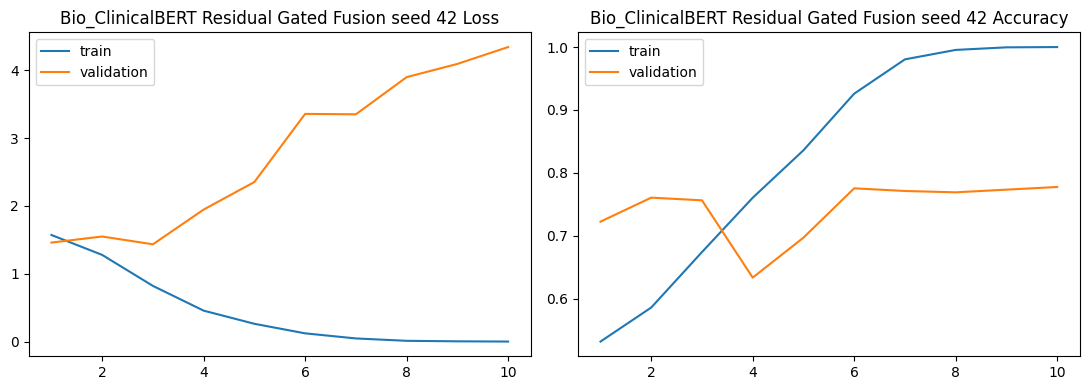

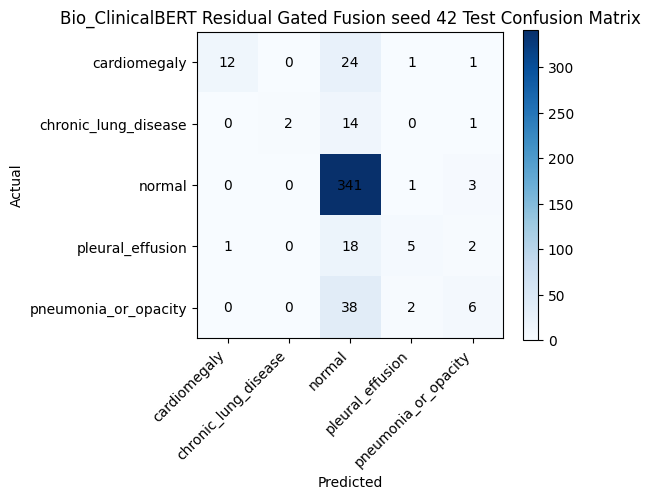

,model,source,seed,best_epoch,best_val_acc,test_loss,test_accuracy,test_macro_f1,checkpoint_path,best_checkpoint_path,last_checkpoint_path,training_curve_path,checkpoint_policy,resumed_from_checkpoint,resume_start_epoch,run_dir
0,Bio_ClinicalBERT residual gated fusion,notebook_03,42,10,0.777542,4.822049,0.775424,0.408916,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,best checkpoint tracks validation accuracy; la...,True,11,PROJECT_ROOT\Exp...


In [30]:
def to_jsonable(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {key: to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    return value


def train_and_evaluate_gated_seed(seed):
    seed_everything(seed)
    run_slug = f"{FUSION_RUN_SLUG}_seed_{seed}"
    run_dir = OUTPUT_DIR / FUSION_RUN_SLUG / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)
    best_checkpoint_path = run_dir / "best_checkpoint.pt"
    last_checkpoint_path = run_dir / "last_checkpoint.pt"

    train_loader, val_loader, test_loader = build_multimodal_loaders(seed)
    model = SelectedEncoderGatedFusionModel(
        encoder_spec=TEXT_ENCODER_SPEC,
        num_classes=num_classes,
        fusion_block=None,
        fusion_dim=256,
        fusion_dropout=0.2,
        freeze_bert=FREEZE_BERT,
        freeze_image_backbone=FREEZE_IMAGE_BACKBONE,
        cache_dir=HF_CACHE_DIR,
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = configure_optimizer(
        model,
        lr_text=LR_TEXT,
        lr_image=LR_IMAGE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda epoch: 1.0)

    def move_optimizer_state_to_device(optimizer, device):
        for state in optimizer.state.values():
            for key, value in state.items():
                if torch.is_tensor(value):
                    state[key] = value.to(device)

    history = []
    best_val_acc = -math.inf
    best_epoch = -1
    start_epoch = 1
    resumed_from_checkpoint = False

    if last_checkpoint_path.exists():
        resume_checkpoint = torch.load(last_checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(resume_checkpoint["model_state_dict"])
        if "optimizer_state_dict" in resume_checkpoint:
            optimizer.load_state_dict(resume_checkpoint["optimizer_state_dict"])
            move_optimizer_state_to_device(optimizer, device)
        if "scheduler_state_dict" in resume_checkpoint:
            scheduler.load_state_dict(resume_checkpoint["scheduler_state_dict"])
        history = list(resume_checkpoint.get("history", []))
        best_val_acc = float(resume_checkpoint.get("best_val_acc", best_val_acc))
        best_epoch = int(resume_checkpoint.get("best_epoch", resume_checkpoint.get("epoch", best_epoch)))
        completed_epoch = int(resume_checkpoint.get("epoch", 0))
        start_epoch = completed_epoch + 1
        resumed_from_checkpoint = True
        print(
            f"Resuming seed {seed} from epoch {completed_epoch}; "
            f"next epoch is {start_epoch}/{EPOCHS}."
        )

    if start_epoch > EPOCHS:
        print(f"Seed {seed} already has a complete last checkpoint at epoch {start_epoch - 1}.")

    for epoch in range(start_epoch, EPOCHS + 1):
        print(f"{SELECTED_ENCODER_NAME} Residual Gated Fusion seed {seed} - Epoch {epoch}/{EPOCHS}")
        train_loss, train_acc = train_epoch_fusion(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )
        val_loss, val_acc, _, _, _ = evaluate_fusion(
            model,
            val_loader,
            criterion,
            device,
        )

        scheduler.step()
        lr_values = [group["lr"] for group in optimizer.param_groups]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr_min": min(lr_values),
            "lr_max": max(lr_values),
        })

        print(
            f"seed={seed} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )
        print()

        is_best = val_acc >= best_val_acc
        if is_best:
            best_val_acc = float(val_acc)
            best_epoch = epoch

        checkpoint_payload = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "encoder_spec": TEXT_ENCODER_SPEC,
            "seed": seed,
            "epoch": epoch,
            "best_epoch": best_epoch,
            "best_val_acc": best_val_acc,
            "current_val_acc": float(val_acc),
            "history": history,
            "label_names": label_names,
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
            "num_workers": NUM_WORKERS,
            "epochs": EPOCHS,
            "lr_text": LR_TEXT,
            "lr_image": LR_IMAGE,
            "weight_decay": WEIGHT_DECAY,
            "max_len": MAX_LEN,
            "freeze_bert": FREEZE_BERT,
            "freeze_image_backbone": FREEZE_IMAGE_BACKBONE,
            "lr_schedule_name": LR_SCHEDULE_NAME,
            "fusion_block": "ResidualGatedFusionBlock",
            "checkpoint_policy": "last checkpoint saved every epoch; best checkpoint saved on validation accuracy improvement",
            "comparison_settings": INHERITED_NOTEBOOK02_SETTINGS,
        }
        torch.save(checkpoint_payload, last_checkpoint_path)
        if is_best:
            torch.save(checkpoint_payload, best_checkpoint_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(run_dir / "training_history.csv", index=False)
    training_curve_path = run_dir / "training_curves.png"
    plot_history(
        history_df,
        f"{SELECTED_ENCODER_NAME} Residual Gated Fusion seed {seed}",
        save_path=training_curve_path,
    )
    print("Saved epoch training curve:", training_curve_path)

    evaluation_checkpoint_path = best_checkpoint_path if best_checkpoint_path.exists() else last_checkpoint_path
    best_checkpoint = torch.load(evaluation_checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    test_loss, test_acc, y_true, y_pred, gate_weights = evaluate_fusion(
        model,
        test_loader,
        criterion,
        device,
    )

    metrics = evaluate_predictions(y_true, y_pred, label_names)
    save_json(to_jsonable(metrics), run_dir / "test_metrics.json")
    save_json(to_jsonable(metrics["classification_report"]), run_dir / "test_classification_report.json")
    pd.DataFrame(metrics["confusion_matrix"], index=label_names, columns=label_names).to_csv(
        run_dir / "test_confusion_matrix.csv"
    )
    save_confusion_matrix_figure(
        metrics["confusion_matrix"],
        f"{SELECTED_ENCODER_NAME} Residual Gated Fusion seed {seed} Test Confusion Matrix",
        run_dir / "test_confusion_matrix.png",
    )

    gate_summary = pd.DataFrame(
        {
            "image_gate_weight": gate_weights[:, 0],
            "text_gate_weight": gate_weights[:, 1],
        }
    )
    gate_summary.to_csv(run_dir / "gate_weights.csv", index=False)

    summary = {
        "model": f"{SELECTED_ENCODER_NAME} residual gated fusion",
        "source": "notebook_03",
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "test_macro_f1": float(metrics["macro_f1"]),
        "checkpoint_path": str(evaluation_checkpoint_path),
        "best_checkpoint_path": str(best_checkpoint_path),
        "last_checkpoint_path": str(last_checkpoint_path),
        "training_curve_path": str(training_curve_path),
        "checkpoint_policy": "best checkpoint tracks validation accuracy; last checkpoint updates every epoch",
        "resumed_from_checkpoint": resumed_from_checkpoint,
        "resume_start_epoch": start_epoch,
        "run_dir": str(run_dir),
    }
    save_json(summary, run_dir / "run_summary.json")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return summary


gated_seed_summaries = []
for seed in EXPERIMENT_SEEDS:
    gated_seed_summaries.append(train_and_evaluate_gated_seed(seed))

gated_seed_summary_df = pd.DataFrame(gated_seed_summaries)
gated_seed_summary_df.to_csv(OUTPUT_DIR / FUSION_RUN_SLUG / "gated_fusion_seed_summary.csv", index=False)
display(gated_seed_summary_df)


### **Summarize Gated Fusion Result**


In [35]:
gated_aggregate_row = {
    "model": f"{SELECTED_ENCODER_NAME} residual gated fusion",
    "source": "notebook_03",
    "test_accuracy_mean": float(gated_seed_summary_df["test_accuracy"].mean()),
    "test_macro_f1_mean": float(gated_seed_summary_df["test_macro_f1"].mean()),
    "val_accuracy_mean": float(gated_seed_summary_df["best_val_acc"].mean()),
    "val_macro_f1_mean": np.nan,
}

gated_aggregate_df = pd.DataFrame([gated_aggregate_row])
gated_aggregate_df.to_csv(OUTPUT_DIR / FUSION_RUN_SLUG / "gated_fusion_aggregate_summary.csv", index=False)
display(gated_aggregate_df)


,model,source,test_accuracy_mean,test_macro_f1_mean,val_accuracy_mean,val_macro_f1_mean
0,Bio_ClinicalBERT residual gated fusion,notebook_03,0.775424,0.408916,0.777542,NaN


### **Gated Fusion Result Interpretation**

The Bio_ClinicalBERT residual gated fusion model achieved the strongest held-out test performance among the compared Notebook 02/03 models. It reached 0.775 test accuracy and 0.409 test macro F1, improving over the standard Bio_ClinicalBERT fusion baseline at 0.763 accuracy and 0.311 macro F1. The macro F1 improvement is especially important because it suggests that the gated image-text interaction improved minority-class performance more than the standard fusion approach.

The gated model also outperformed the dual-view image baseline on both test accuracy and macro F1, while the Bio_ClinicalBERT text-only model remained substantially weaker. These results support carrying the residual gated fusion architecture forward into the later segmentation-preprocessing, Grad-CAM interpretability, and tuning notebooks as the preferred multimodal backbone.

However, the result should not be treated as a guaranteed improvement over the previous fusion method. The gated model's best validation accuracy was 0.778, slightly below the standard fusion baseline's 0.784, and validation macro F1 was not available for the gated aggregate. Although the held-out test results favor gated fusion, the weaker validation accuracy suggests that the improvement is not completely consistent across splits. For that reason, the gated model is the strongest current candidate, but later experiments should determine whether its advantage remains stable.


---

# **Part 4: Results and Reporting**

### **Compare Model Performance**


In [36]:
comparison_df = pd.concat(
    [notebook02_baselines_df, gated_aggregate_df],
    ignore_index=True,
)
comparison_df = comparison_df.sort_values(
    ["test_accuracy_mean", "test_macro_f1_mean"],
    ascending=[False, False],
).reset_index(drop=True)
comparison_df = comparison_df.drop(columns=["seed"], errors="ignore")

comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
display(comparison_df)


,model,source,test_accuracy_mean,test_macro_f1_mean,val_accuracy_mean,val_macro_f1_mean
0,Bio_ClinicalBERT residual gated fusion,notebook_03,0.775424,0.408916,0.777542,NaN
1,Bio_ClinicalBERT standard fusion baseline,notebook_02,0.762712,0.311435,0.783898,0.433231
2,Dual-view image baseline,notebook_02,0.756356,0.359514,0.766949,0.431304
3,Bio_ClinicalBERT text-only baseline,notebook_02,0.502119,0.202833,0.495763,0.240602


---

# **Part 5: Conclusion**

The Bio_ClinicalBERT residual gated fusion model is the strongest test-set result in this comparison. It reached 0.775 test accuracy and 0.409 test macro F1, improving over the Notebook 02 standard Bio_ClinicalBERT fusion baseline at 0.763 accuracy and 0.311 macro F1. It also outperformed the dual-view image baseline, while the text-only baseline remained much weaker. The important point is not only that accuracy increased, but that macro F1 improved substantially, which suggests the gated fusion block helped the model use image and report signals in a more balanced way.

This result supports carrying residual gated fusion forward as the preferred multimodal architecture. The residual connection gives the model a direct fused representation while the gate can learn how strongly to mix modalities for each case. In practice, that makes this experiment a better foundation for the later segmentation and interpretability work than the simpler concatenation-style fusion baseline.

It is also important to consider that the gated model did not dominate every validation metric. Its best validation accuracy was 0.778, which is slightly below the standard fusion baseline's 0.784. The test-set gain, especially in macro F1, supports carrying residual gated fusion forward into the segmentation-preprocessing ablation before Grad-CAM interpretation. Future notebooks will help verify whether the architecture remains strong when the image inputs are cropped or masked, and whether the same checkpoint produces interpretable case-level evidence.

---